In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tbparse

2024-12-12 06:24:54.189433: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-12 06:24:54.189486: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-12 06:24:54.189498: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-12 06:24:54.197586: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [54]:
final_csv_path = 'result_csvs/FINAL.csv'
final_df = pd.read_csv(final_csv_path)
final_df['label'] = final_df[['model','train_data','test_data']].apply(lambda x:'\n'.join(x), axis=1)
final_df['label_set'] = (final_df['model'], final_df['train_data'], final_df['test_data'])
final_df['percent_epochs'] = final_df['train_epochs']/final_df['max_epochs']

In [55]:
final_df.columns

Index(['model', 'train_data', 'test_data', 'device', 'timestamp',
       'n_hyperparam_trials', 'learning_rate', 'batch_size',
       'accum_grad_batches', 'max_epochs', 'feature_length', 'dim_mlp_layers',
       'train_steps', 'train_epochs', 'test_auroc', 'test_loss',
       'train_walltime', 'hyperparam_json_path', 'hyperparam_log_path',
       'train_log_path', 'test_log_path', 'trained_model_ckpt_path',
       'tested_model_ckpt_path', 'label', 'label_set', 'percent_epochs'],
      dtype='object')

In [7]:
# get dataframe from lightning log
def get_df_from_log(log_path):
    reader = tbparse.SummaryReader(log_path)
    return reader.scalars

In [51]:
# get dfs from paths
hyperparam_dfs = {}
train_dfs = {}
test_dfs = {}

for index,row in final_df.iterrows():
    h_df = get_df_from_log(row.hyperparam_log_path)
    hyperparam_dfs[(row.model,row.train_data,row.test_data)] = h_df
    train_df = get_df_from_log(row.train_log_path)
    train_dfs[(row.model,row.train_data,row.test_data)] = train_df
    test_df = get_df_from_log(row.test_log_path)
    test_dfs[(row.model,row.train_data,row.test_data)] = test_df

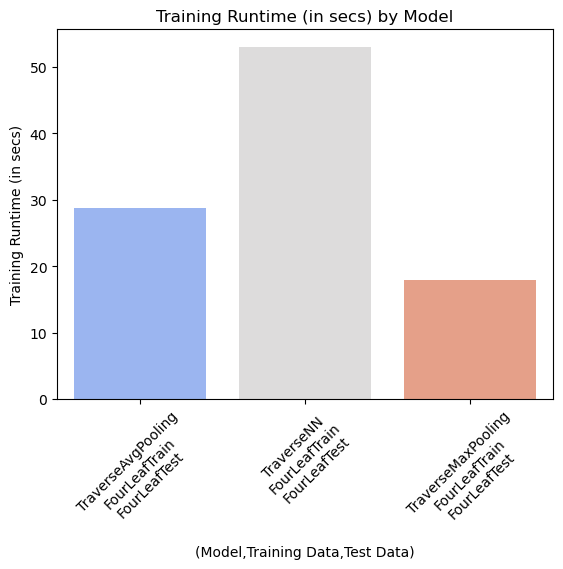

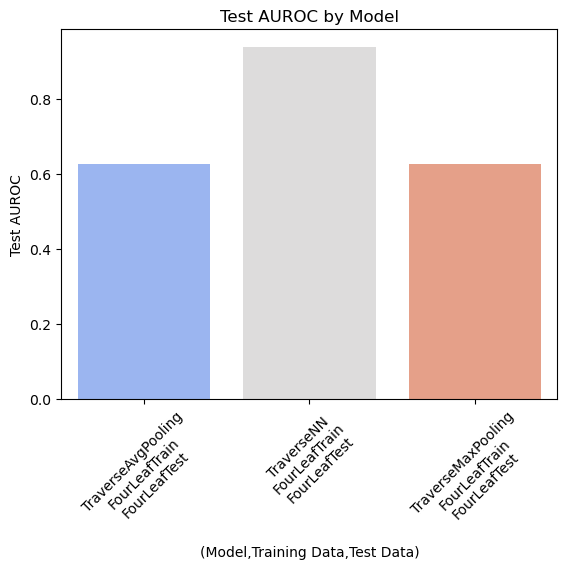

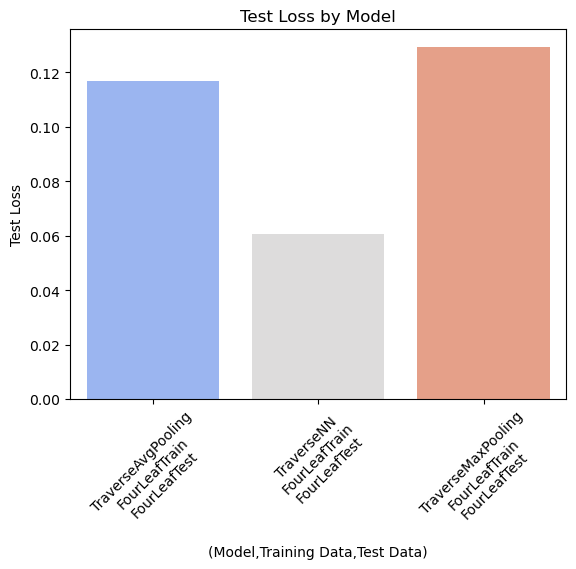

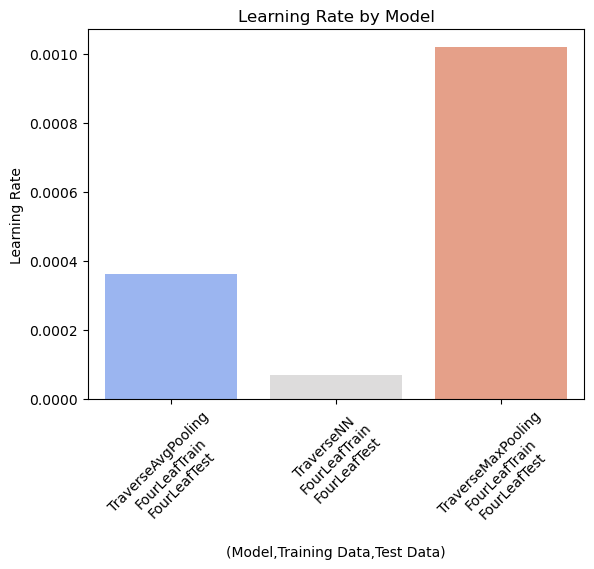

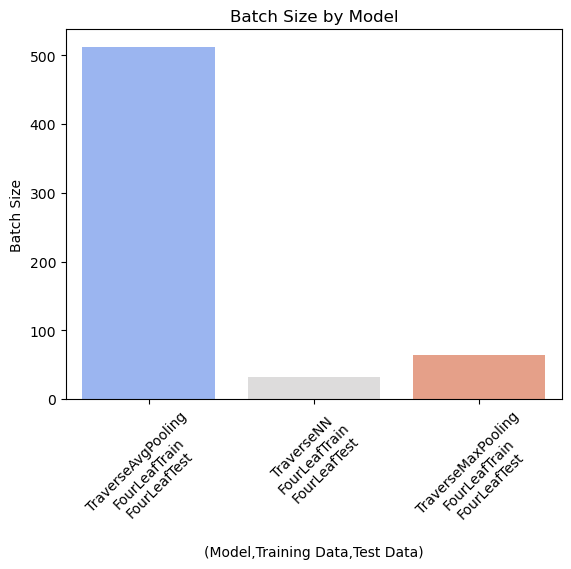

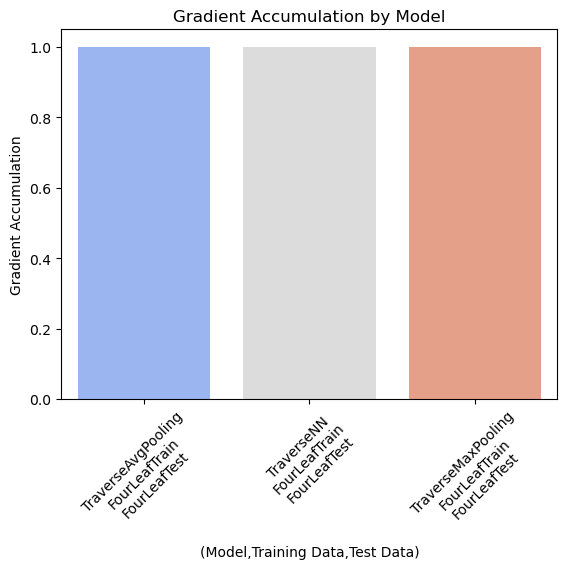

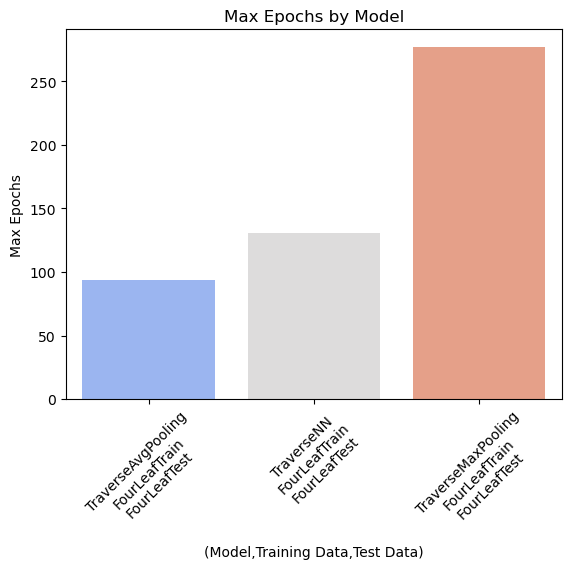

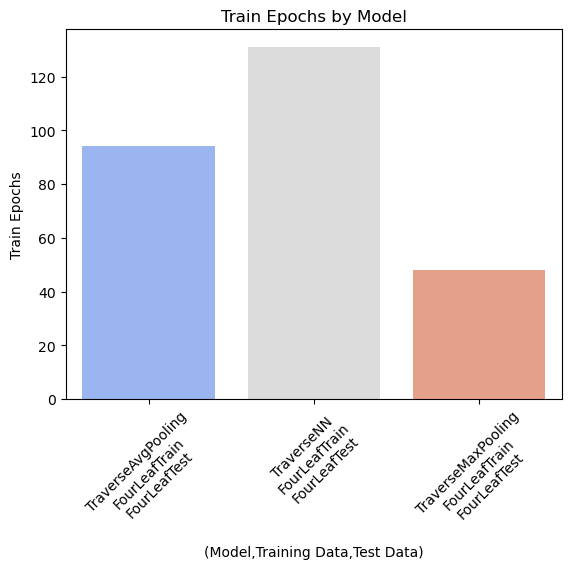

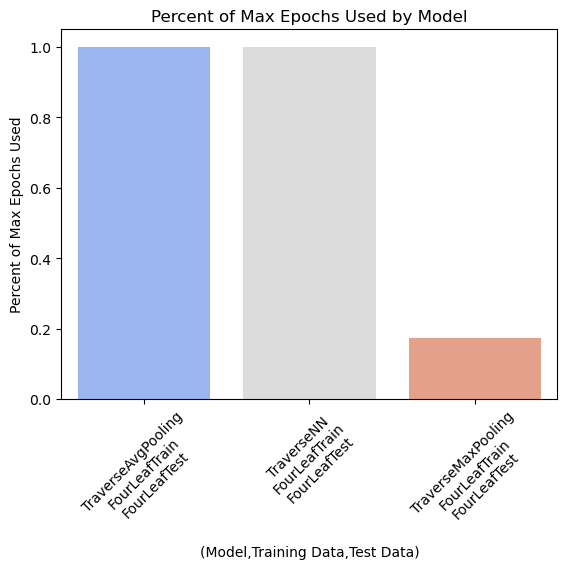

In [56]:
# bar plots
x_measures = {
  "Training Runtime (in secs)": "train_walltime",
  "Test AUROC": "test_auroc",
  "Test Loss": "test_loss",
  "Learning Rate": "learning_rate",
  "Batch Size": "batch_size",
  "Gradient Accumulation": "accum_grad_batches",
  "Max Epochs": "max_epochs",
  "Train Epochs": "train_epochs",
  "Percent of Max Epochs Used": "percent_epochs",
}

for x_title,x_col in x_measures.items():
    sns.barplot(x="label", y=f"{x_col}", data=final_df, hue="label", palette='coolwarm')
    plt.xlabel("(Model,Training Data,Test Data)")
    plt.ylabel(f"{x_title}")
    plt.title(f"{x_title} by Model")
    plt.xticks(rotation=45)
    plt.show()

/tmp/ipykernel_1250/878998528.py:10: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_tag.step, df_tag.value, label=key)


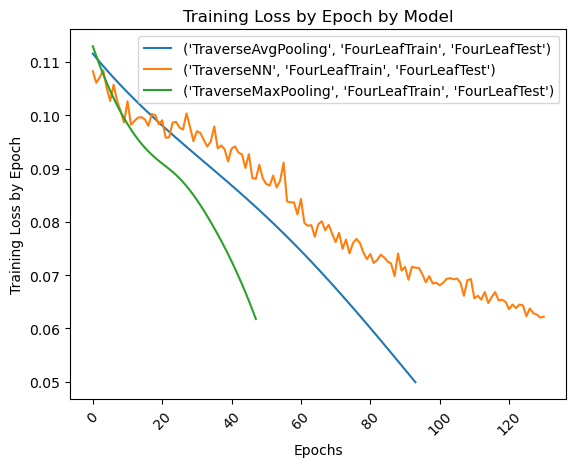

In [50]:
# line plots over epochs (using lightning logs)

x_measures = {
  "Training Loss by Epoch": "train_loss_epoch",
}

for x_title,x_col in x_measures.items():
    for key,df in train_dfs.items():
        df_tag = df[df.tag == x_col]
        plt.plot(df_tag.step, df_tag.value, label=key)

    plt.xlabel("Epochs")
    plt.ylabel(f"{x_title}")
    plt.title(f"{x_title} by Model")
    plt.xticks(rotation=45)

    plt.legend()
    plt.show()